In [2]:
#importing libraries
import pandas as pd 
import numpy as np

In [3]:
surveys_df = pd.read_csv("data/surveys.csv")
surveys_df.head(5)

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight
0,1,7,16,1977,2,NL,M,32.0,NaN
1,2,7,16,1977,3,NL,M,33.0,NaN
2,3,7,16,1977,2,DM,F,37.0,NaN
3,4,7,16,1977,7,DM,M,36.0,NaN
4,5,7,16,1977,3,DM,M,35.0,NaN


In [4]:
type(surveys_df)

pandas.core.frame.DataFrame

In [5]:
surveys_df.dtypes

record_id            int64
month                int64
day                  int64
year                 int64
plot_id              int64
species_id          object
sex                 object
hindfoot_length    float64
weight             float64
dtype: object

In [6]:
surveys_df.columns

Index(['record_id', 'month', 'day', 'year', 'plot_id', 'species_id', 'sex',
       'hindfoot_length', 'weight'],
      dtype='object')

In [7]:
surveys_df.shape

(35549, 9)

In [8]:
pd.unique(surveys_df['species_id'])

array(['NL', 'DM', 'PF', 'PE', 'DS', 'PP', 'SH', 'OT', 'DO', 'OX', 'SS',
       'OL', 'RM', nan, 'SA', 'PM', 'AH', 'DX', 'AB', 'CB', 'CM', 'CQ',
       'RF', 'PC', 'PG', 'PH', 'PU', 'CV', 'UR', 'UP', 'ZL', 'UL', 'CS',
       'SC', 'BA', 'SF', 'RO', 'AS', 'SO', 'PI', 'ST', 'CU', 'SU', 'RX',
       'PB', 'PL', 'PX', 'CT', 'US'], dtype=object)

In [9]:
site_names = pd.unique(surveys_df['plot_id'])
site_names

array([ 2,  3,  7,  1,  6,  5,  8,  4, 11, 14, 15, 13,  9, 10, 17, 16, 20,
       23, 18, 21, 22, 19, 12, 24])

In [10]:
print(len(site_names))
print(surveys_df['plot_id'].nunique())
print(surveys_df['plot_id'].value_counts())

24
24
plot_id
12    2365
2     2194
17    2039
1     1995
4     1969
9     1936
11    1918
8     1891
14    1885
3     1828
6     1582
13    1538
18    1445
22    1399
20    1390
5     1194
19    1189
21    1173
15    1069
24    1048
7      816
16     646
23     571
10     469
Name: count, dtype: int64


In [11]:
surveys_df['weight'].describe()


count    32283.000000
mean        42.672428
std         36.631259
min          4.000000
25%         20.000000
50%         37.000000
75%         48.000000
max        280.000000
Name: weight, dtype: float64

In [12]:
print(f'min = {surveys_df['weight'].min()}')
print(f'max = {surveys_df['weight'].max()}')
print(f'mean = {surveys_df['weight'].mean()}')
print(f'std = {surveys_df['weight'].std()}')
print(f'count = {surveys_df['weight'].count()}')

min = 4.0
max = 280.0
mean = 42.672428212991356
std = 36.63125947458358
count = 32283


In [13]:
grouped_data = surveys_df.groupby('sex')
# Summary statistics for all numeric columns by sex
grouped_data.describe()


record_id                                                               \
        count          mean           std  min      25%      50%       75%   
sex                                                                          
F     15690.0  18036.412046  10423.089000  3.0  8917.50  18075.5  27250.00   
M     17348.0  17754.835601  10132.203323  1.0  8969.75  17727.5  26454.25   

                month            ... hindfoot_length         weight  \
         max    count      mean  ...             75%   max    count   
sex                              ...                                  
F    35547.0  15690.0  6.583047  ...            36.0  64.0  15303.0   
M    35548.0  17348.0  6.392668  ...            36.0  58.0  16879.0   

                                                         
          mean        std  min   25%   50%   75%    max  
sex                                                      
F    42.170555  36.847958  4.0  20.0  34.0  46.0  274.0  
M    42.995379  36.184981  4.0  20.0  39.0  49.0  280.0  

[2 rows x 56 columns]

In [14]:
# Provide the mean for each numeric column by sex
grouped_data.mean(numeric_only=True)

,record_id,month,day,year,plot_id,hindfoot_length,weight
sex,,,,,,,
F,18036.412046,6.583047,16.007138,1990.644997,11.440854,28.836780,42.170555
M,17754.835601,6.392668,16.184286,1990.480401,11.098282,29.709578,42.995379


In [15]:
gender_counts = surveys_df['sex'].value_counts()
gender_counts

sex
M    17348
F    15690
Name: count, dtype: int64

In [16]:
grouped_data2 = surveys_df.groupby(['plot_id', 'sex'])
grouped_means = grouped_data2.mean(numeric_only=True)
grouped_means

record_id     month        day         year  hindfoot_length  \
plot_id sex                                                                    
1       F    18390.384434  6.597877  15.338443  1990.933962        31.733911   
        M    17197.740639  6.121461  15.905936  1990.091324        34.302770   
2       F    17714.753608  6.426804  16.288660  1990.449485        30.161220   
        M    18085.458042  6.340035  15.440559  1990.756119        30.353760   
3       F    19888.783875  6.604703  16.161254  1992.013438        23.774044   
        M    20226.767857  6.271429  16.450000  1992.275000        23.833744   
4       F    17489.205275  6.442661  15.746560  1990.235092        33.249102   
        M    18493.841748  6.430097  16.507767  1991.000971        34.097959   
5       F    12280.793169  6.142315  15.722960  1986.485769        28.921844   
        M    12798.426621  6.194539  15.703072  1986.817406        29.694794   
6       F    19406.503392  6.628223  16.313433  1991.579376        26.981322   
        M    17849.574607  6.035340  16.091623  1990.556283        27.425591   
7       F    19069.668657  6.385075  15.313433  1991.441791        19.779553   
        M    19188.729642  6.719870  15.778502  1991.462541        20.536667   
8       F    18920.276190  6.632143  15.836905  1991.267857        32.187578   
        M    19452.109868  6.571719  15.854527  1991.686673        33.751059   
9       F    16217.497069  6.499414  15.555686  1989.303634        35.126092   
        M    18000.710159  6.361554  15.209163  1990.632470        34.175732   
10      F    16001.496454  5.588652  16.964539  1989.248227        18.641791   
        M    15708.704225  5.718310  16.739437  1989.007042        19.567164   
11      F    16994.962287  6.759124  16.283455  1989.836983        32.029299   
        M    16933.909621  6.374150  15.974733  1989.856171        32.078014   
12      F    17457.966981  6.509434  16.305660  1990.266981        30.975124   
        M    17592.327500  6.304167  16.367500  1990.400833        31.762489   
13      F    18033.100318  6.802548  16.229299  1990.619427        27.201014   
        M    16969.044700  6.480204  16.005109  1989.911877        27.893793   
14      F    17097.145275  6.510578  16.681241  1989.974612        32.973373   
        M    17891.948598  6.660748  16.504673  1990.587850        32.961802   
15      F    20602.449064  6.569647  16.162162  1992.523909        21.949891   
        M    18104.019560  6.185819  17.413203  1990.770171        21.803109   
16      F    19002.445946  6.360360  16.819820  1991.351351        23.144928   
        M    18434.714286  6.201465  16.622711  1990.926740        23.480916   
17      F    18234.322870  6.650224  15.892377  1990.785874        30.918536   
        M    18857.651472  6.569801  16.183286  1991.331434        32.227634   
18      F    17940.875497  6.698013  15.960265  1990.536424        26.690341   
        M    15106.718850  6.610224  16.797125  1988.551118        27.703072   
19      F    21848.216475  6.701149  15.226054  1993.417625        21.257937   
        M    19470.779690  6.533563  16.647160  1991.740103        21.071685   
20      F    17510.769231  6.743077  16.026154  1990.253846        27.069193   
        M    16076.192496  6.489396  16.375204  1989.243067        27.908451   
21      F    22452.636661  6.860884  16.307692  1993.878887        22.366554   
        M    20120.399113  6.671840  16.203991  1992.199557        21.736721   
22      F    18499.695976  6.651267  15.521610  1990.973174        34.108320   
        M    18015.365527  6.381872  16.682021  1990.650817        33.359746   
23      F    15863.193939  6.860606  16.036364  1989.024242        20.051948   
        M    17091.338164  6.391304  16.077295  1989.961353        19.850000   
24      F    13702.224280  6.596708  16.393004  1987.485597        26.993377   
        M    15208.136082  6.360825  16.971134  1988.641237        25.786996   

               

In [17]:
grouped_data3 = surveys_df.groupby(['plot_id'])
weight_summary = grouped_data3['weight'].describe()
weight_summary

,count,mean,std,min,25%,50%,75%,max
plot_id,,,,,,,,
1,1903.0,51.822911,38.176670,4.0,30.0,44.0,53.0,231.0
2,2074.0,52.251688,46.503602,5.0,24.0,41.0,50.0,278.0
3,1710.0,32.654386,35.641630,4.0,14.0,23.0,36.0,250.0
4,1866.0,47.928189,32.886598,4.0,30.0,43.0,50.0,200.0
5,1092.0,40.947802,34.086616,5.0,21.0,37.0,48.0,248.0
6,1463.0,36.738893,30.648310,5.0,18.0,30.0,45.0,243.0
7,638.0,20.663009,21.315325,4.0,11.0,17.0,23.0,235.0
8,1781.0,47.758001,33.192194,5.0,26.0,44.0,51.0,178.0
9,1811.0,51.432358,33.724726,6.0,36.0,45.0,50.0,275.0


In [18]:
species_counts = surveys_df.groupby('species_id')['record_id'].count()
species_counts

species_id
AB      303
AH      437
AS        2
BA       46
CB       50
CM       13
CQ       16
CS        1
CT        1
CU        1
CV        1
DM    10596
DO     3027
DS     2504
DX       40
NL     1252
OL     1006
OT     2249
OX       12
PB     2891
PC       39
PE     1299
PF     1597
PG        8
PH       32
PI        9
PL       36
PM      899
PP     3123
PU        5
PX        6
RF       75
RM     2609
RO        8
RX        2
SA       75
SC        1
SF       43
SH      147
SO       43
SS      248
ST        1
SU        5
UL        4
UP        8
UR       10
US        4
ZL        2
Name: record_id, dtype: int64

In [19]:
surveys_df.groupby('species_id')['record_id'].count()['DO']


np.int64(3027)

In [20]:
species_counts = surveys_df.groupby('species_id').count()['record_id']
species_counts


species_id
AB      303
AH      437
AS        2
BA       46
CB       50
CM       13
CQ       16
CS        1
CT        1
CU        1
CV        1
DM    10596
DO     3027
DS     2504
DX       40
NL     1252
OL     1006
OT     2249
OX       12
PB     2891
PC       39
PE     1299
PF     1597
PG        8
PH       32
PI        9
PL       36
PM      899
PP     3123
PU        5
PX        6
RF       75
RM     2609
RO        8
RX        2
SA       75
SC        1
SF       43
SH      147
SO       43
SS      248
ST        1
SU        5
UL        4
UP        8
UR       10
US        4
ZL        2
Name: record_id, dtype: int64

In [21]:
new_df = surveys_df
new_df = new_df['weight']*2
new_df.head(5)


0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: weight, dtype: float64

In [22]:
new_df.describe()

count    32283.000000
mean        85.344856
std         73.262519
min          8.000000
25%         40.000000
50%         74.000000
75%         96.000000
max        560.000000
Name: weight, dtype: float64

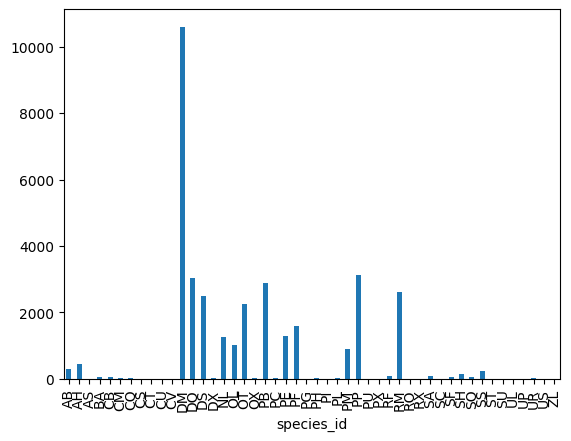

In [23]:
%matplotlib inline
species_counts.plot(kind='bar');

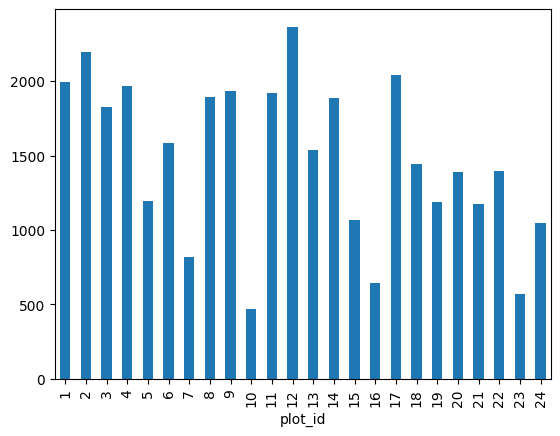

In [24]:
total_count = surveys_df.groupby('plot_id')['record_id'].nunique()
# Let's plot that too
total_count.plot(kind='bar');

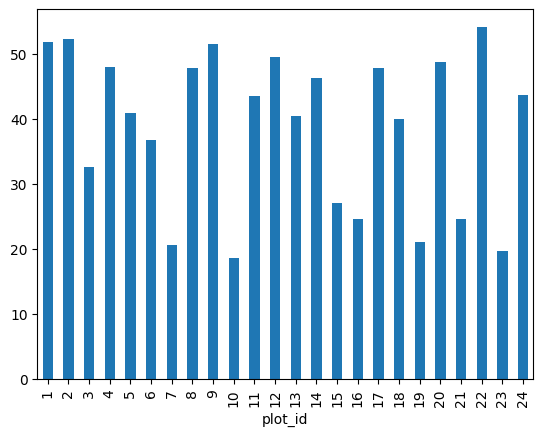

In [25]:
average_weight = surveys_df.groupby('plot_id')['weight'].mean()
# Let's plot that too
average_weight.plot(kind='bar');

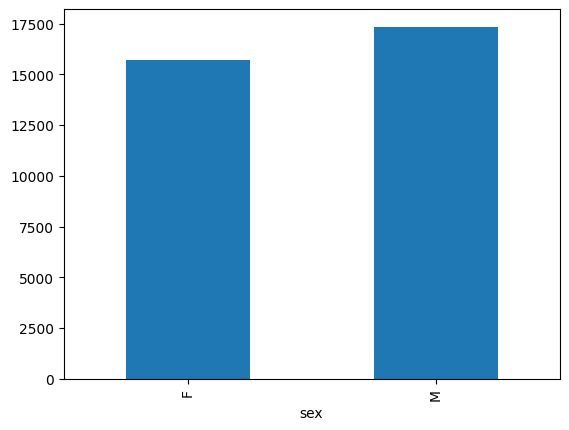

In [26]:
total_mvf = surveys_df.groupby('sex')['record_id'].count()
# Let's plot that too
total_mvf.plot(kind='bar');

In [27]:
surveys_species = surveys_df.species_id
surveys_species

0         NL
1         NL
2         DM
3         DM
4         DM
        ... 
35544     AH
35545     AH
35546     RM
35547     DO
35548    NaN
Name: species_id, Length: 35549, dtype: object

In [28]:
surveys_df[['species_id', 'plot_id']]


,species_id,plot_id
0,NL,2
1,NL,3
2,DM,2
3,DM,7
4,DM,3
...,...,...
35544,AH,15
35545,AH,15
35546,RM,10
35547,DO,7


In [29]:
surveys_df[['plot_id', 'species_id']]


,plot_id,species_id
0,2,NL
1,3,NL
2,2,DM
3,7,DM
4,3,DM
...,...,...
35544,15,AH
35545,15,AH
35546,10,RM
35547,7,DO


In [30]:
a = [1, 2, 3, 4, 5]

In [31]:
for column in surveys_df.columns:
    print(column, len(surveys_df[surveys_df[column].isna()]))

record_id 0
month 0
day 0
year 0
plot_id 0
species_id 763
sex 2511
hindfoot_length 4111
weight 3266


In [32]:
df_na = surveys_df.dropna()


In [33]:
df_na.shape

(30676, 9)

In [34]:
df_na.to_csv('data/surveys_complete.csv', index=False)

In [35]:
%matplotlib inline
import plotnine as p9

In [36]:
surveys_complete = pd.read_csv('data/surveys.csv')
surveys_complete = surveys_complete.dropna()

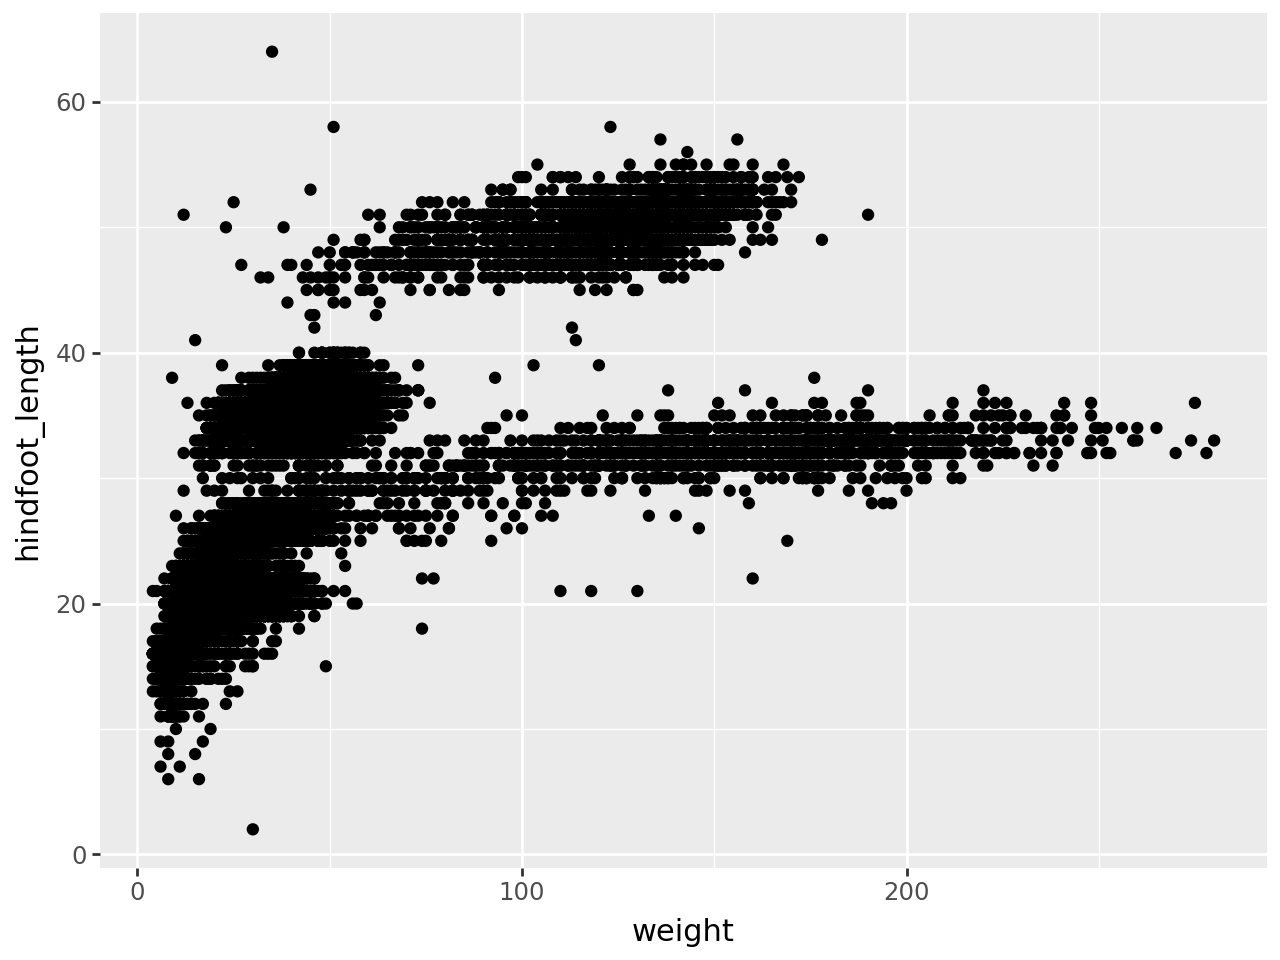

In [37]:
(p9.ggplot(data=surveys_complete,
           mapping=p9.aes(x='weight', y='hindfoot_length')) + p9.geom_point())


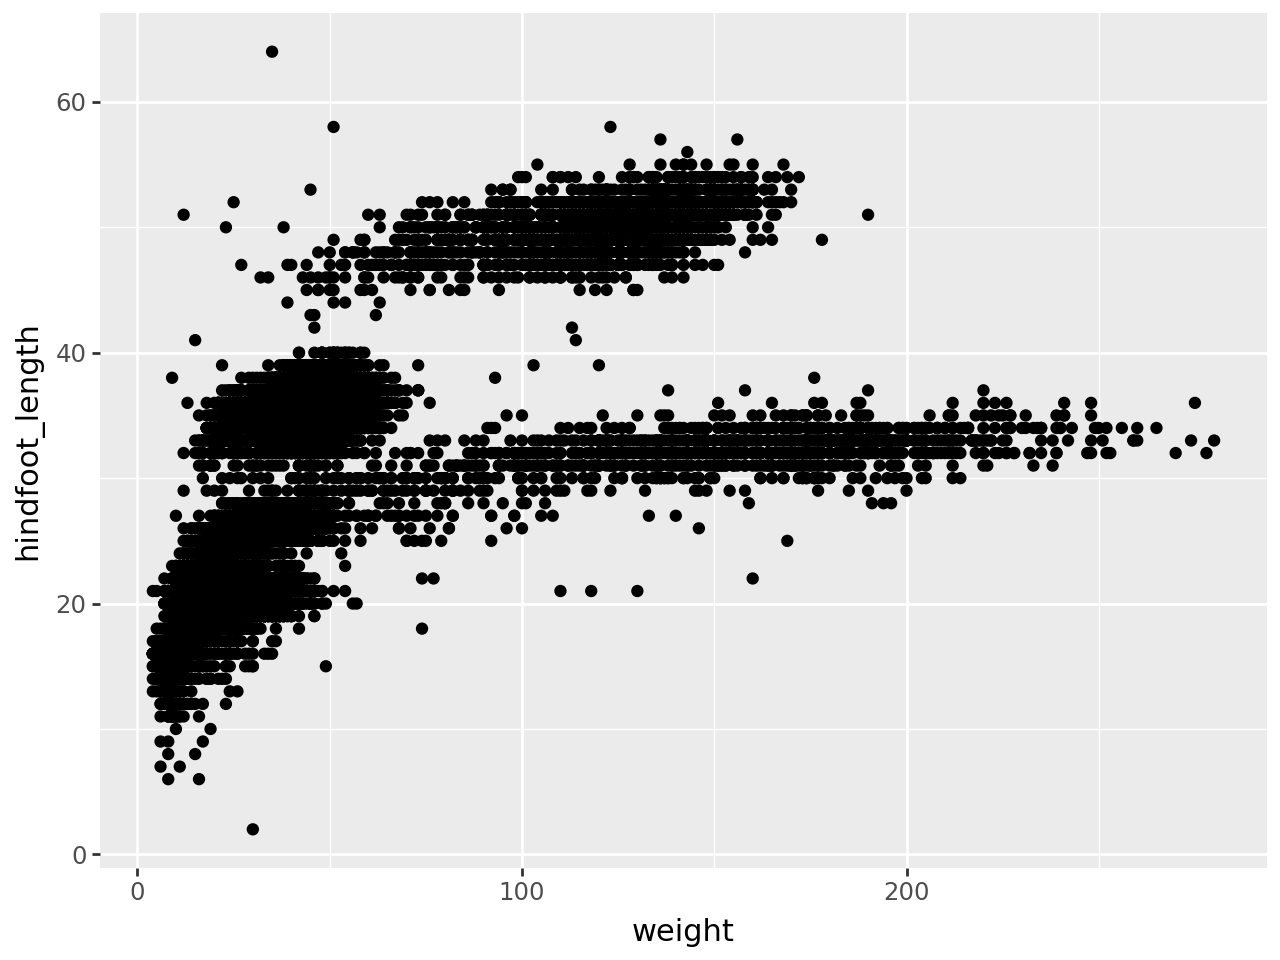

In [38]:
# Create
surveys_plot = p9.ggplot(data=surveys_complete,
                         mapping=p9.aes(x='weight', y='hindfoot_length'))

# Draw the plot
surveys_plot + p9.geom_point()

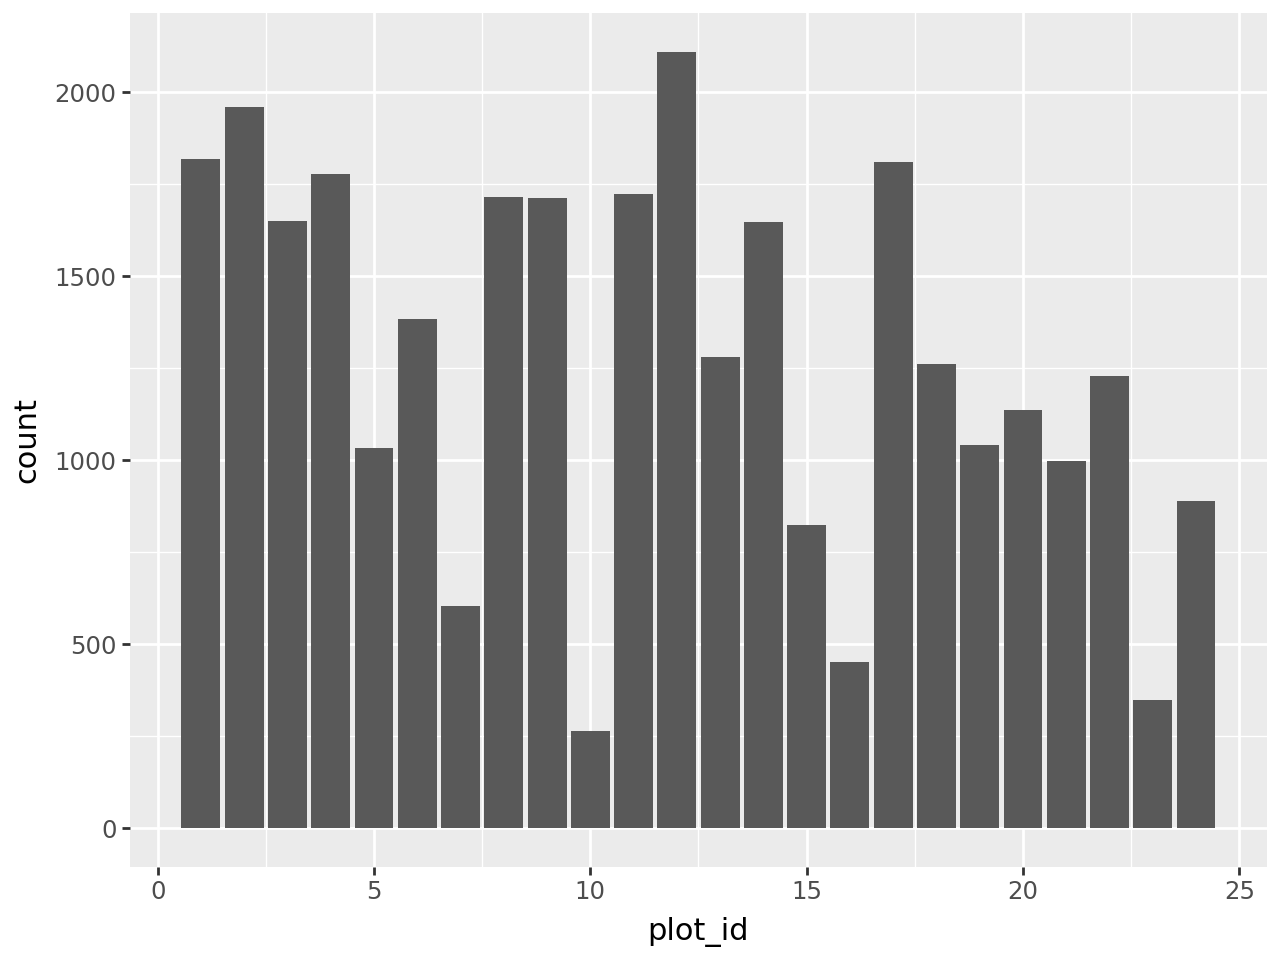

In [39]:
surveys_plot = p9.ggplot(data=surveys_complete,
                         mapping=p9.aes(x='plot_id'))

# Draw the plot
surveys_plot + p9.geom_bar()

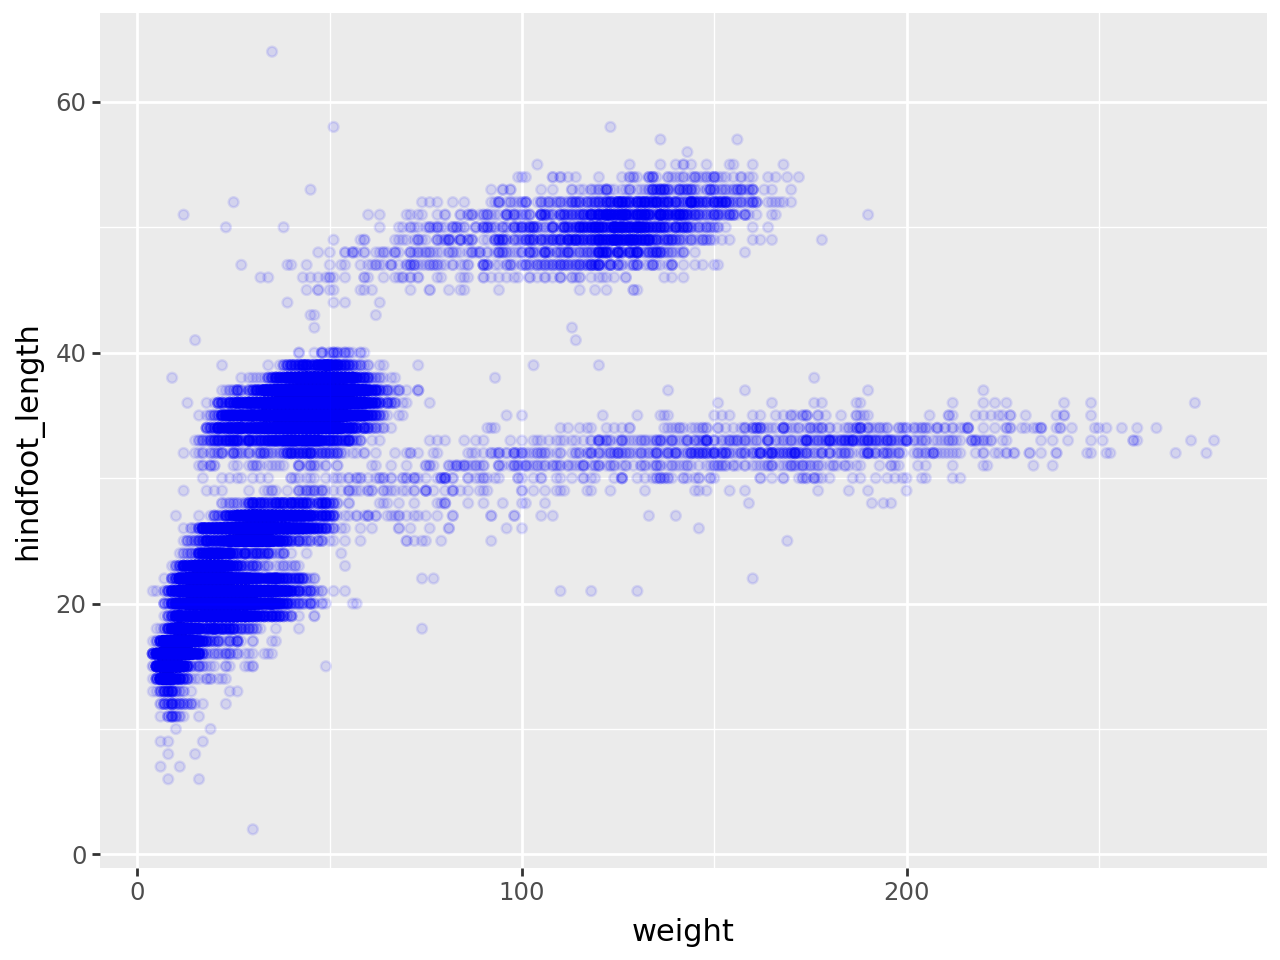

In [40]:
(p9.ggplot(data=surveys_complete,
           mapping=p9.aes(x='weight', y='hindfoot_length'))
    + p9.geom_point(alpha=0.1, color='blue')
)

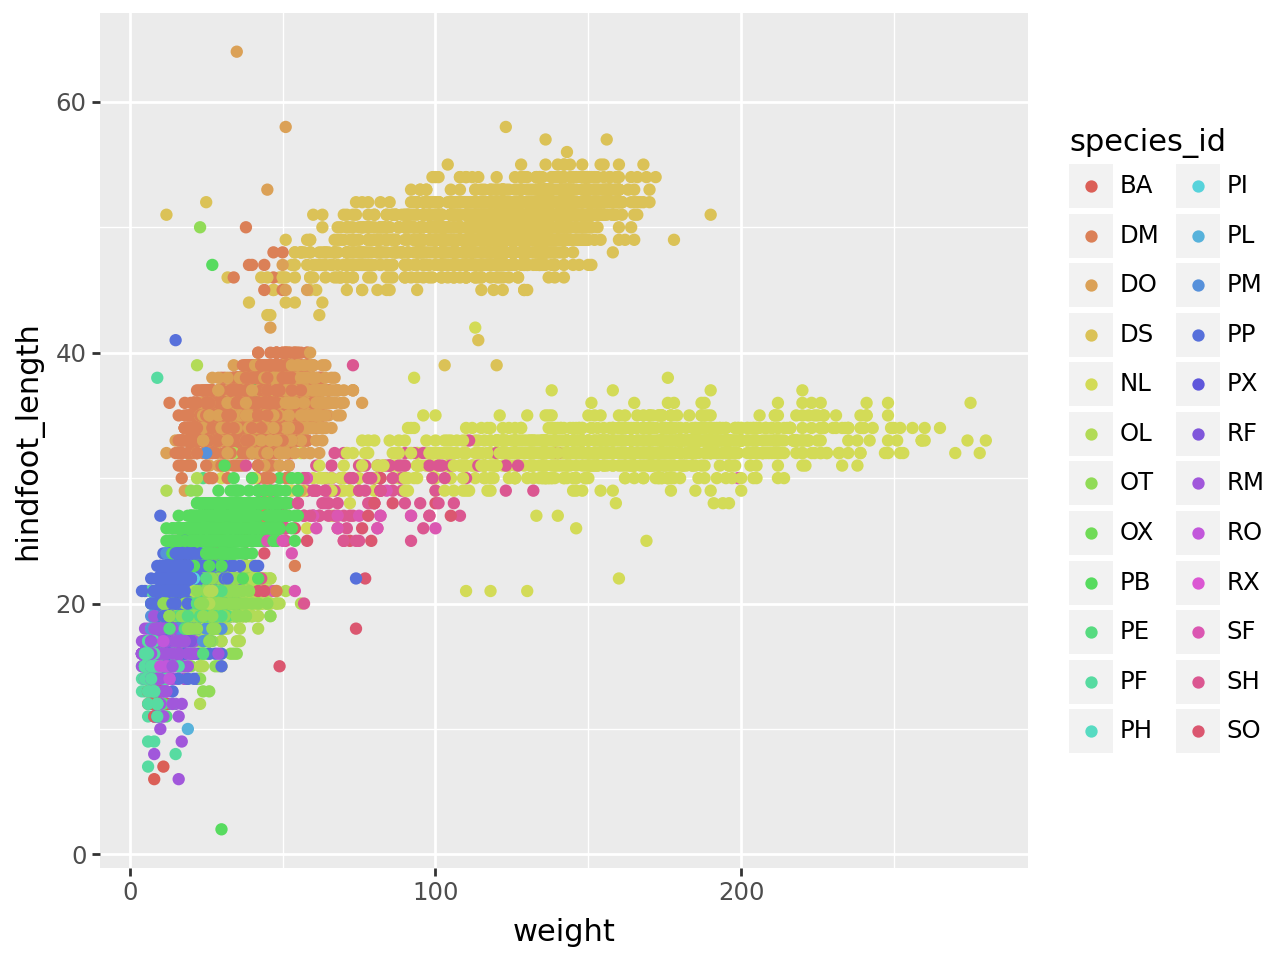

In [41]:
(p9.ggplot(data=surveys_complete,
           mapping=p9.aes(x='weight', y='hindfoot_length', color='species_id'))
    + p9.geom_point()
)

In [42]:
(p9.ggplot(data=surveys_complete,
           mapping=p9.aes(x='weight', y='hindfoot_length', color='species_id'))
    + p9.geom_point()
    + p9.xlab("Weight (g)")
    + p9.ylab("Length (cm)")
    + p9.scale_x_log10()
    + p9.theme_bw()
    + p9.theme(text= p9.element_text(size=12))
).save("plot.png")

c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:615: PlotnineWarning: Saving 6.4 x 4.8 in image.
c:\Users\MTP24ME\AppData\Local\Programs\Python\Python312\Lib\site-packages\plotnine\ggplot.py:616: PlotnineWarning: Filename: plot.png


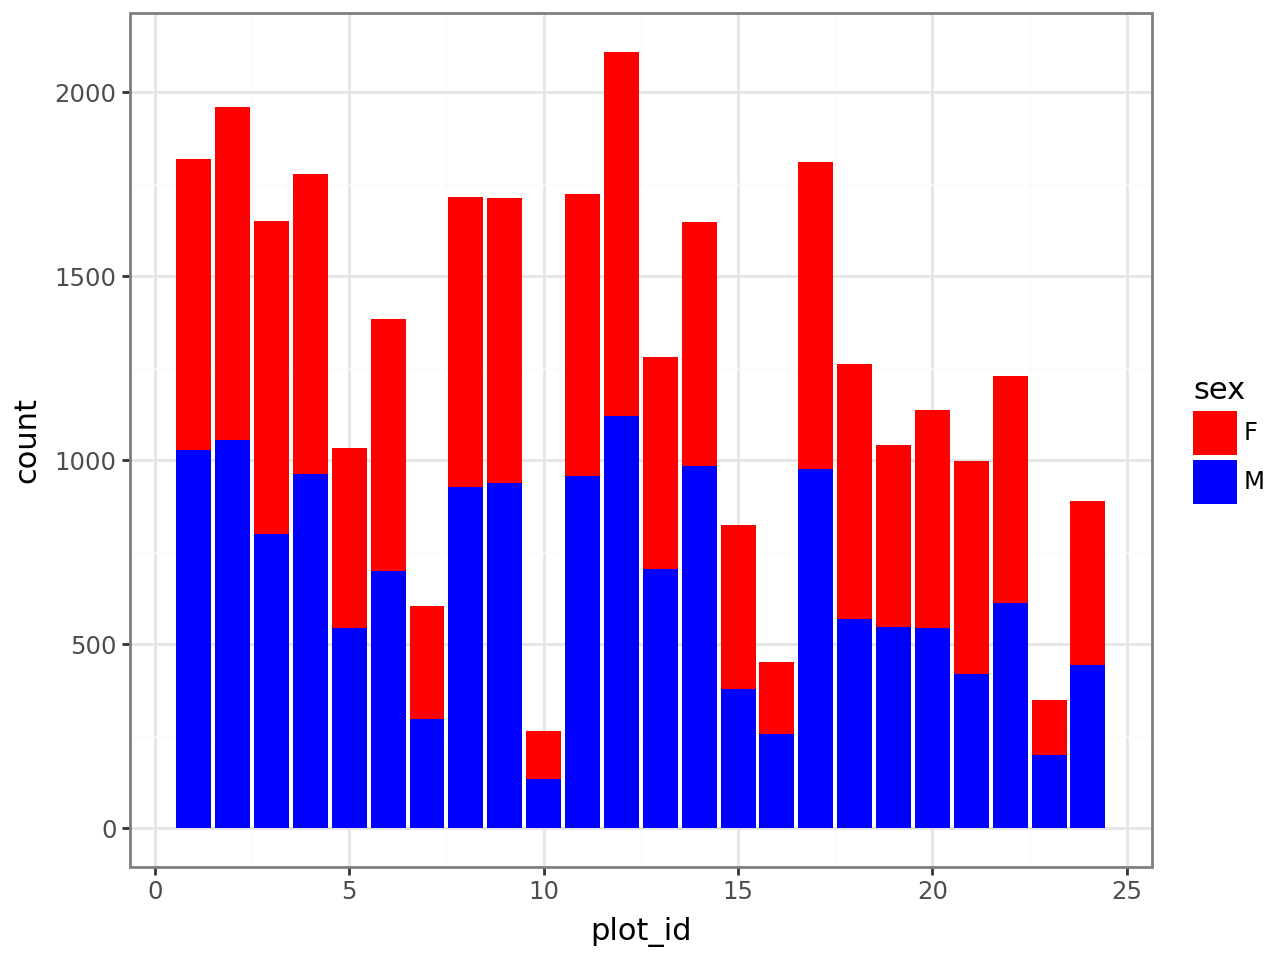

In [43]:
p9.options.dpi= 100
(p9.ggplot(data=surveys_complete,
           mapping=p9.aes(x='plot_id',
                          fill='sex'))
    + p9.geom_bar()
    + p9.scale_fill_manual(["red", "blue"])
    + p9.theme_bw()
) 


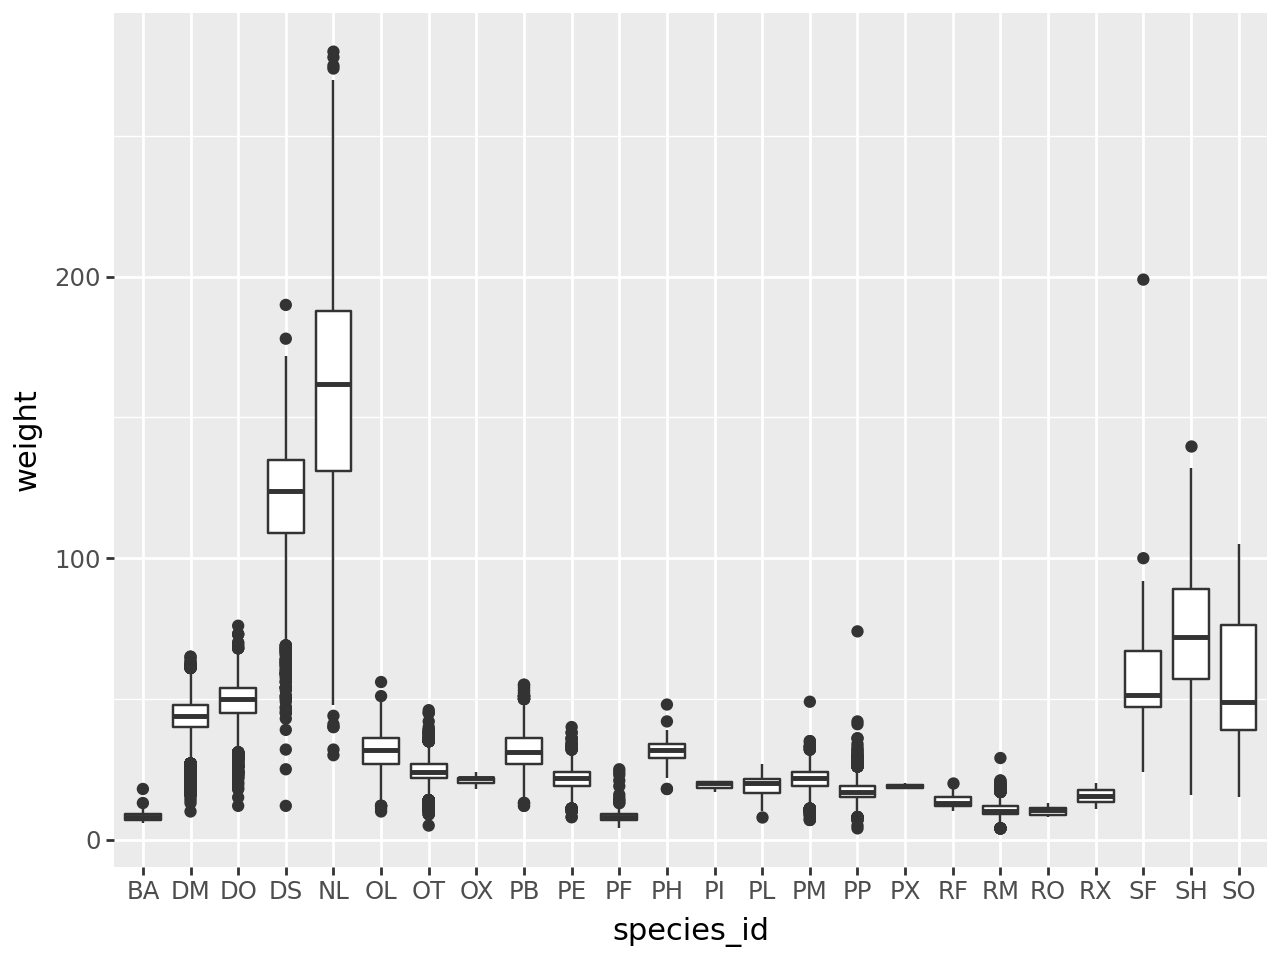

In [44]:
(p9.ggplot(data=surveys_complete,
           mapping=p9.aes(x='species_id',
                          y='weight'))
    + p9.geom_boxplot()
)

In [49]:
import skimpy

skimpy.skim(surveys_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 35549  │ │ int64       │ 5     │                                                          │
│ │ Number of columns │ 9      │ │ string      │ 2     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column_name        ┃ NA    ┃ NA %    ┃ mean   ┃ sd     ┃ p0    ┃ p25   ┃ p50    ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │ record_id          │     0 │       0 │  17780 │  10260 │     1 │  8888 │  17780 │  26660 │  35550 │ ▇▇▇▇▇▇ │  │
│ │ month              │     0 │       0 │  6.474 │  3.397 │     1 │     4 │      6 │      9 │     12 │ ▆▇▇▇▇▇ │  │
│ │ day                │     0 │       0 │  16.11 │  8.257 │     1 │     9 │     16 │     23 │     31 │ ▅▆▇▆▇▆ │  │
│ │ year               │     0 │       0 │   1990 │  7.493 │  1977 │  1984 │   1990 │   1997 │   2002 │ ▅▆▆▅▆▇ │  │
│ │ plot_id            │     0 │       0 │   11.4 │  6.799 │     1 │     5 │     11 │     17 │     24 │ ▇▅▇▅▆▅ │  │
│ │ hindfoot_length    │  4111 │   11.56 │  29.29 │  9.565 │     2 │    21 │     32 │     36 │     70 │  ▇▆▆▁  │  │
│ │ weight             │  3266 │    9.19 │  42.67 │  36.63 │     4 │    20 │     37 │     48 │    280 │  ▇▁▁   │  │
│ └────────────────────┴───────┴─────────┴────────┴────────┴───────┴───────┴────────┴────────┴────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column_name              ┃ NA         ┃ NA %       ┃ words per row               ┃ total words             ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ species_id               │        763 │       2.15 │                        0.98 │                   34786 │  │
│ │ sex                      │       2511 │       7.06 │                        0.93 │                   33038 │  │
│ └──────────────────────────┴────────────┴────────────┴─────────────────────────────┴─────────────────────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯